<a href="https://colab.research.google.com/github/negativespace-exe/Econometrics-Work/blob/main/Assignment_6_ECON_6550.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.8 MB/s eta 0:00:00


In [21]:
import requests
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
import statsmodels.formula.api as smf

from linearmodels.iv import IV2SLS



##Precipitation as a function of lake-level change (and vice versa!)
My thought for this assignment was to construct two simple equations modeling the lake level of the Great Salt Lake against precipitation and vice versa. These are simultaneous systems because the lake produces lake-effect snow (which, admittedly, is mostly seasonal), and the precipitation that falls contributes to the lake level, including spring runoff from winter snowpack in the Wasatch Mountains.

I constructed my initial naive models:

**2SLS Regressors (Stage Two)**
\begin{equation}
LakeLevel_{t} = \alpha_0 + \alpha_1\hat{Precipitation_t} + u_t
\end{equation}

\begin{equation}
Precipitation_t = \beta_0 + \beta_1\hat{LakeLevel_t} + v_t
\end{equation}


I then gathered data on the daily lake level of the Great Salt Lake from 2000-2026 as well as daily precipitation totals from NRCS at the SNOTEL at Snowbird for the same time period. I merged the datasets, and plotted the two variables against one another to see if there was indeed some kind of association.

In [2]:
#importing SLC lake level data and cleaning slightly
url = (
    "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data"
    "?stationTriplets=766:UT:SNTL"
    "&elements=PRCP"
    "&duration=DAILY"
    "&beginDate=2000-01-01"
    "&endDate=2026-10-02"
)

response = requests.get(url)
response.raise_for_status()

data = response.json()
values = data[0]["data"][0]["values"]

precip = pd.DataFrame(values)

precip = precip[["date", "value"]].copy()

precip = precip.rename(columns={
    "value": "precipitation_in"
})

precip["date"] = pd.to_datetime(precip["date"])

precip.to_csv("snowbird_daily_precipitation_2000_2026.csv", index=False)

precip.head()

,date,precipitation_in
0,2000-01-01,0.0
1,2000-01-02,0.7
2,2000-01-03,0.6
3,2000-01-04,0.7
4,2000-01-05,0.5


In [3]:
#reading in Snowbird precipitation data and cleaning it

file_id = "1P7Q15KPMcLD7_NafMr94LrEs26INoSAY"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

lake = pd.read_csv(url)

lake = lake[["time", "value"]].copy()

lake = lake.rename(columns={
    "time": "date",
    "value": "lake_level_ft"
})

lake["date"] = pd.to_datetime(lake["date"])

lake.head()


,date,lake_level_ft
0,2000-01-01,4202.5
1,2000-01-02,4202.5
2,2000-01-03,4202.5
3,2000-01-04,4202.4
4,2000-01-05,4202.5


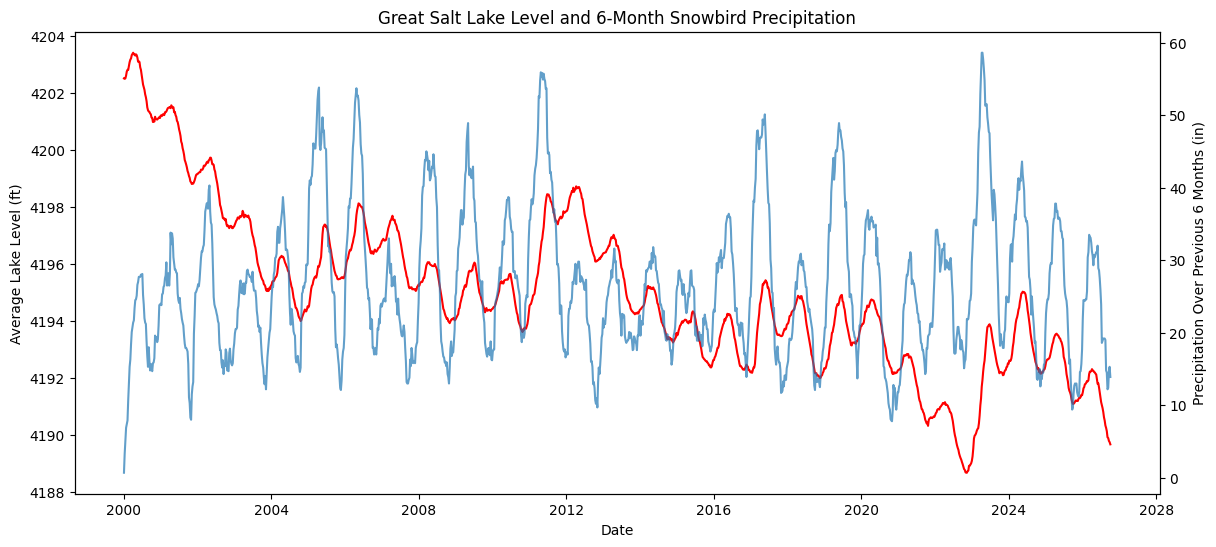

In [5]:
# exploratory visualization of data

# making sure dates are in the right format
lake["date"] = pd.to_datetime(lake["date"])
precip["date"] = pd.to_datetime(precip["date"])

# make sure precipitation is sorted by date
precip = precip.sort_values("date")

# calculate precipitation over the preceding ~6 months
precip["precip_6mo"] = (
    precip.set_index("date")["precipitation_in"]
          .rolling("183D")
          .sum()
          .values
)

# reduce to weekly observations
precip_6mo_weekly = (
    precip.set_index("date")
          .resample("W")["precip_6mo"]
          .last()
          .reset_index()
)

# average lake level for each week
lake_weekly = (
    lake.set_index("date")
        .resample("W")
        ["lake_level_ft"]
        .mean()
        .reset_index()
)

# merging datasets
weekly = lake_weekly.merge(
    precip_6mo_weekly,
    on="date",
    how="inner"
)

# plotting values
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    weekly["date"],
    weekly["lake_level_ft"],
    label="Average Lake Level",
    color="red"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Average Lake Level (ft)")

# second y axis
ax2 = ax1.twinx()

ax2.plot(
    weekly["date"],
    weekly["precip_6mo"],
    alpha=0.7,
    label="6-Month Precipitation"
)
ax2.set_ylabel("Precipitation Over Previous 6 Months (in)")

plt.title("Great Salt Lake Level and 6-Month Snowbird Precipitation")
plt.show()

The first time I created the above visualization, I plotted average lake level per week against the weekly precipitation total. But the graph was so busy it was almost impossible to read. I decided instead to calcuate the total precipitation over the past 6 months for any given moment and then plot that. Doing that demonstrates a visually evident association between lake level and precipitation received over the past 6 months.

I wondered if there were other time frames that might be more appropriate, so I played around with that a bit:

In [6]:
# playing with different time frames: rolling month, 3 month, 6 month, 9 month, and 12 month rolling averages
precip = precip.sort_values("date").copy()
precip = precip.set_index("date")

# rolling precipitation totals
precip["precip_1mo"]  = precip["precipitation_in"].rolling("30D").sum()
precip["precip_3mo"]  = precip["precipitation_in"].rolling("91D").sum()
precip["precip_6mo"]  = precip["precipitation_in"].rolling("183D").sum()
precip["precip_9mo"]  = precip["precipitation_in"].rolling("274D").sum()
precip["precip_12mo"] = precip["precipitation_in"].rolling("365D").sum()

# converting to weekly values
precip_rolling_weekly = (
    precip[
        ["precip_1mo", "precip_3mo", "precip_6mo",
         "precip_9mo", "precip_12mo"]
    ]
    .resample("W")
    .last()
    .reset_index()
)

rolling = lake_weekly.merge(
    precip_rolling_weekly,
    on="date",
    how="inner"
)

# calculate association of lake level with each precipitation window
windows = [
    "precip_1mo",
    "precip_3mo",
    "precip_6mo",
    "precip_9mo",
    "precip_12mo"
]

#checking correlation
for window in windows:
    r = rolling["lake_level_ft"].corr(rolling[window])
    print(f"{window}: {r:.3f}")

precip_1mo: -0.050
precip_3mo: 0.034
precip_6mo: 0.090
precip_9mo: -0.005
precip_12mo: -0.140


I realized at this point that the correlation values were quite low despite a visually apparent association between the variables. And that was because I was looking at the lake data as a static figure!

I realized that what I actually wanted to do was try to correlate *change* in the lake level and precipitation over the previous six months.

In [8]:
# creating variable for difference in lake level rather than using lake level itself as a variable
rolling["lake_level_change"] = (
    rolling["lake_level_ft"].diff()
)

# redefining windows using change of lake level
windows = [
    "precip_1mo",
    "precip_3mo",
    "precip_6mo",
    "precip_9mo",
    "precip_12mo"
]

#checking correlation
for window in windows:
    r = rolling["lake_level_change"].corr(rolling[window])
    print(f"{window}: {r:.3f}")

precip_1mo: 0.677
precip_3mo: 0.714
precip_6mo: 0.395
precip_9mo: 0.115
precip_12mo: 0.255


The correlation was much higher after framing the variables in this way, and the 3 month window looked the best.  I ran a simple OLS regression on the data and found an $R^2$ value of 0.51, which means about half of the variation in the rate of change of level of the Great Salt Lake can be explained by precipitation totals over the previous 3 months.

In [9]:
# ols regression
df = rolling

ols = smf.ols(
    "lake_level_change ~ precip_3mo",
    data=df
).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:      lake_level_change   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     1450.
Date:                Sun, 04 Oct 2026   Prob (F-statistic):          4.34e-218
Time:                        22:24:41   Log-Likelihood:                 1636.6
No. Observations:                1396   AIC:                            -3269.
Df Residuals:                    1394   BIC:                            -3259.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1557      0.004    -35.879      0.0

The *precip_3mo* coefficient is 0.0110, which I will try to beat using an IV/2SLS model.

But first, I wanted to visualize the correlation between the variables using a scatter plot, and it's evident that the change in lake level does move with precipitation totals.

I tried coloring the data points by date, to see if there was a tendency for higher or lower precipitation amounts overall as time went on. The points seemed relatively evenly distributed, however.

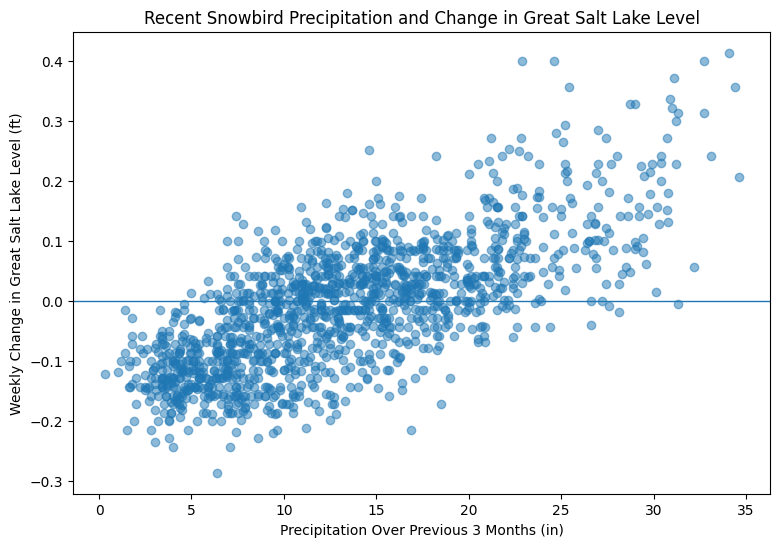

In [10]:
#visualizing weekly lake-level change against previous 3-month precipitation total
plt.figure(figsize=(9, 6))

plt.scatter(
    rolling["precip_3mo"],
    rolling["lake_level_change"],
    alpha=0.5
)

plt.xlabel("Precipitation Over Previous 3 Months (in)")
plt.ylabel("Weekly Change in Great Salt Lake Level (ft)")
plt.title("Recent Snowbird Precipitation and Change in Great Salt Lake Level")

plt.axhline(0, linewidth=1)

plt.show()

One thing I noticed from the original line chart (in my exploratory analysis) was that there were obvious bumps in both precipitation and lake level that roughly seemed to correlate with seasonality.

So I thought that for my 2SLS model, I would try using season itself as an explanatory variable for my IV equation, estimating precipitation as a function of precipitation by season (Fall will be the base/default season).

**Independent variable regressor (Stage One)**

\begin{equation}
\hat{Precipitation_t} = \gamma_0 + \gamma_1Spring_t + \gamma_2Summer_t + \gamma_3Winter_t
\end{equation}

In [11]:
# creating seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "fall"

#assigning seasons
df["season"] = df["date"].dt.month.apply(get_season)

#reorganizing the df
df[["date", "season", "precip_3mo"]].head(20)

,date,season,precip_3mo
0,2000-01-02,winter,0.7
1,2000-01-09,winter,3.3
2,2000-01-16,winter,5.0
3,2000-01-23,winter,6.9
4,2000-01-30,winter,7.4
5,2000-02-06,winter,7.9
6,2000-02-13,winter,10.7
7,2000-02-20,winter,13.0
8,2000-02-27,winter,15.3
9,2000-03-05,spring,16.3


In [12]:
# does average precipitation differ by season? (Yes!)
df.groupby("season")["precip_3mo"].mean()

,precip_3mo
season,
fall,8.370845
spring,18.658310
summer,9.004789
winter,16.972384


I then ran an OLS regression for the IV model, using categorical variables for Spring, Summer, and Winter (Fall being the default variable).

In [13]:
first_stage_season = smf.ols(
    "precip_3mo ~ C(season)",
    data=df
).fit()

print(first_stage_season.summary())

                            OLS Regression Results                            
Dep. Variable:             precip_3mo   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     369.3
Date:                Sun, 04 Oct 2026   Prob (F-statistic):          1.94e-176
Time:                        22:27:46   Log-Likelihood:                -4277.7
No. Observations:                1397   AIC:                             8563.
Df Residuals:                    1393   BIC:                             8584.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               8.3708    

From this regression, I got the the following coefficients for the seasons:
* Fall(intercept): 8.37
* Spring: 10.29
* Summer: 0.63
* Winter: 8.6

My IV model then becomes:

\begin{equation}
\hat{Precipitation_t} = 8.37 + 10.29Spring_t + 0.63Summer_t + 8.6Winter_t
\end{equation}


Now I'm ready to run my 2SLS model and see what happens! (I'm running it manually here with OLS for both stages but will use the specific IV/2SLS regressor later, when dealing with residuals.)


In [14]:
# adding precip_hat values

df["precip_hat"] = first_stage_season.fittedvalues

df[
    ["date", "season", "precip_3mo", "precip_hat"]
].head(20)

,date,season,precip_3mo,precip_hat
0,2000-01-02,winter,0.7,16.972384
1,2000-01-09,winter,3.3,16.972384
2,2000-01-16,winter,5.0,16.972384
3,2000-01-23,winter,6.9,16.972384
4,2000-01-30,winter,7.4,16.972384
5,2000-02-06,winter,7.9,16.972384
6,2000-02-13,winter,10.7,16.972384
7,2000-02-20,winter,13.0,16.972384
8,2000-02-27,winter,15.3,16.972384
9,2000-03-05,spring,16.3,18.658310


In [15]:
# regressing change in lake level on precipitation predicted by season
second_stage = smf.ols(
    "lake_level_change ~ precip_hat",
    data=df
).fit()

print(second_stage.summary())

                            OLS Regression Results                            
Dep. Variable:      lake_level_change   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     703.1
Date:                Sun, 04 Oct 2026   Prob (F-statistic):          8.83e-126
Time:                        22:28:18   Log-Likelihood:                 1424.0
No. Observations:                1396   AIC:                            -2844.
Df Residuals:                    1394   BIC:                            -2834.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1873      0.007    -26.336      0.0

Something I found interesting is that the $R^2$ value actually went down from 0.51 with the regular OLS model to 0.34 with the IV/2SLS model. I initially expected it to be better because I expected that a model that removes some of the variance in precipitation due to lake effect would make the overall fit better. But since *precip_hat* is using only the variation explained by season, it makes sense that the $R^2$ value will have to go down.


The coefficent of *precip_hat* is 0.0134, which is better than the *precip_3mo* coefficient of 0.0110. It looks like a tiny increase, but at this scale, that's actually a full 22% increase! So the season-predicted part of the precipitation variable is better at predicting lake-level change than *precip_3mo* alone.

So is this model a good instrument?

* **Relevance:** the F-statistic of stage one was F=369.3, which shows that the model does have a lot of relevance.
* **Exclusion:** does season's association with change in lake level operate only through precipitation? Almost certainly no. There are many different factors affected by seasonality including (but not limited to) temperature and evaporation.

So this instrument is strong, but not exogenous.

As I was working on this assignment, I became more and more aware of how the variables I had chosen (and any others I could think of) are almost all dependent on the others. Lake level is tied to precipitation for sure, but things like temperature and windspeed are going to affect lake levels through evaporation, and temperature varies with season while windspeed often fluxuates with temperature. In complex systems like this where so many variables are interdependent, it seems like it would be really difficult to construct a true model that either explains or predicts something like a meteorological phenomenon in terms of other, what might seem to be "relevant" variables.

## Dealing with standard error
The time factor is  consequential in my model, because weather patterns such as precipitation and temperature move continuously and contiguously from one value to another. Past values do have an impact on future ones, meaning that they are serially correlated.

I'm first going to examine the residuals to see how best to handle the standard error.

<Figure size 800x600 with 0 Axes>

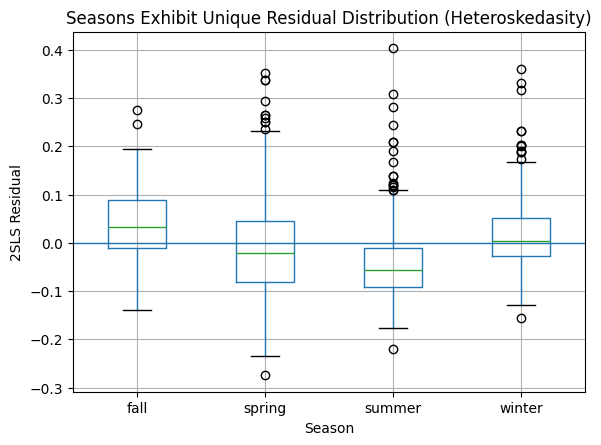

In [16]:
# saving 2SLS residuals
iv_resid = second_stage.resid

# looking for heteroskedasticity in residuals vs fitted values
plt.figure(figsize=(8, 6))

df_plot = df.loc[second_stage.resid.index].copy()
df_plot["residual"] = second_stage.resid

df_plot.boxplot(
    column="residual",
    by="season"
)

plt.axhline(0, linewidth=1)
plt.xlabel("Season")
plt.ylabel("2SLS Residual")
plt.title("Seasons Exhibit Unique Residual Distribution (Heteroskedasity)")
plt.suptitle("")

plt.show()


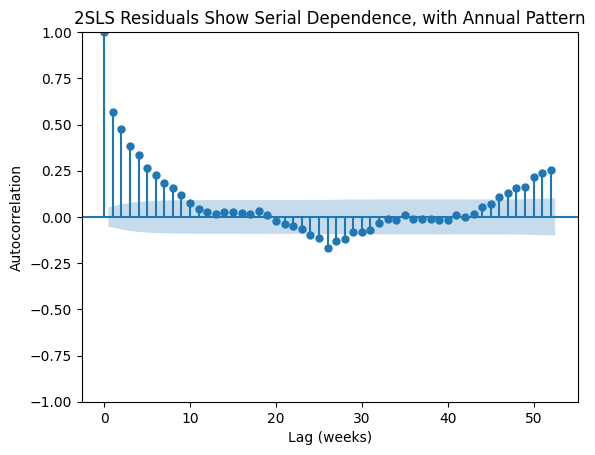

In [17]:
# looking at correlation between residuals across weeks (autocorrelation function (ACF))
plot_acf(
    iv_resid.dropna(),
    lags=52
)

plt.xlabel("Lag (weeks)")
plt.ylabel("Autocorrelation")
plt.title("2SLS Residuals Show Serial Dependence, with Annual Pattern")

plt.show()


In [18]:

# testing for heteroskedasticity in 2SLS with Breusch-Pagan test (does the variance of errors stay constant?)
bp_test = het_breuschpagan(
    iv_resid,
    second_stage.model.exog
)

bp_labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

print("Breusch-Pagan Test")
for label, value in zip(bp_labels, bp_test):
    print(f"{label}: {value:.4f}")

# testing for autocorrelation with Breusch-Godfrey tests (are errors related to previous errors?)
print("\nBreusch-Godfrey Test")

for lag in [1, 4, 8, 12, 26, 52]:

    bg_test = acorr_breusch_godfrey(
        second_stage,
        nlags=lag
    )

    print(
        f"{lag:2d} weeks: "
        f"LM p-value = {bg_test[1]:.4g}"
    )


Breusch-Pagan Test
LM Statistic: 8.8702
LM p-value: 0.0029
F Statistic: 8.9141
F p-value: 0.0029

Breusch-Godfrey Test
 1 weeks: LM p-value = 2.227e-100
 4 weeks: LM p-value = 9.623e-111
 8 weeks: LM p-value = 3.596e-107
12 weeks: LM p-value = 9.462e-104
26 weeks: LM p-value = 1.935e-97
52 weeks: LM p-value = 1.532e-89


/tmp/ipykernel_936/2216331617.py:23: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  bg_test = acorr_breusch_godfrey(


**The F p-value of the Breusch-Pagan test,** (which tests a null hypothesis stating that error variance in the model is constant) is 0.0029, meaning we reject the hypothesis and the data exhibits heteroskedasticity.

**The LM p-values of the Breusch-Godfrey test,** (which tests a null hypothesis stating that the covariance of the errors is 0) are super small at every number of weeks, meaning we again reject the null hypothesis and the data exhibits autocorrelation in the errors.


So we are dealing with both heteroskedasticity and autocorrelation in this data and should therefore find a way to handle the standard errors in a way that addresses what is going on. My IV/2SLS model is currenly assuming the residuals are uncorrelated.

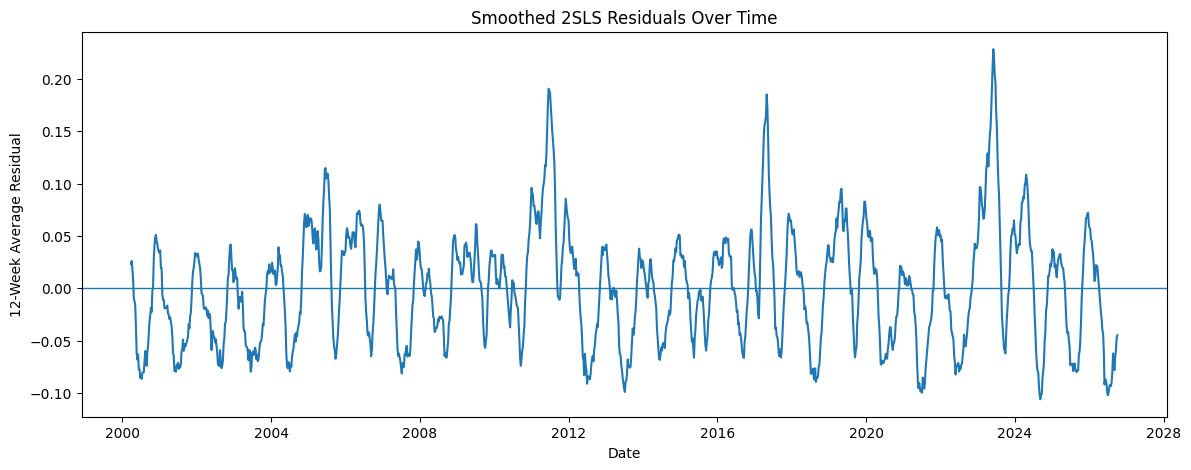

In [19]:
# smoothing residuals over time for readability
resid_df = pd.DataFrame({
    "date": df.loc[iv_resid.index, "date"],
    "residual": iv_resid
})

resid_df["residual_12wk_avg"] = (
    resid_df["residual"]
    .rolling(12)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    resid_df["date"],
    resid_df["residual_12wk_avg"]
)

plt.axhline(0, linewidth=1)
plt.xlabel("Date")
plt.ylabel("12-Week Average Residual")
plt.title("Smoothed 2SLS Residuals Over Time")

plt.show()

The above visualization of the residuals makes it very clear that they are serially connected to each other. So we will need to calculate the SE in a particular way.

I loaded my dataset into R because I have been using a package (called "sandwich"!) that allows testing of various variance/covariance matrix estimators all at once. I tested several estimators and then created a visualization of the results:

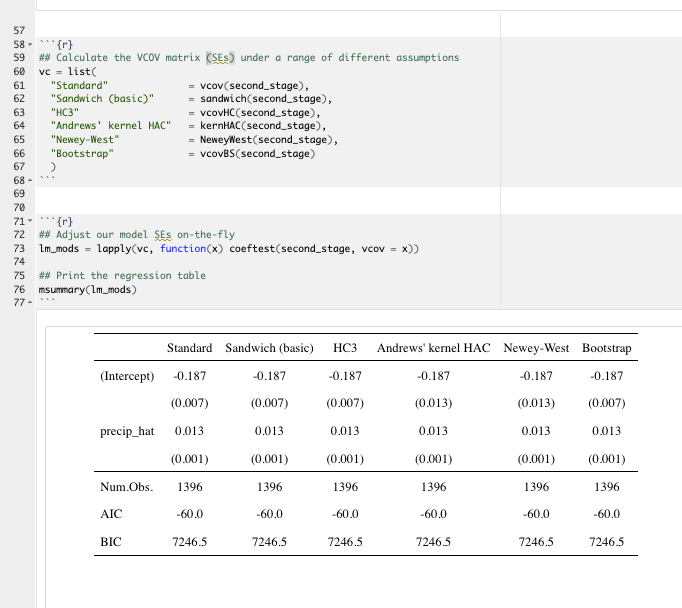

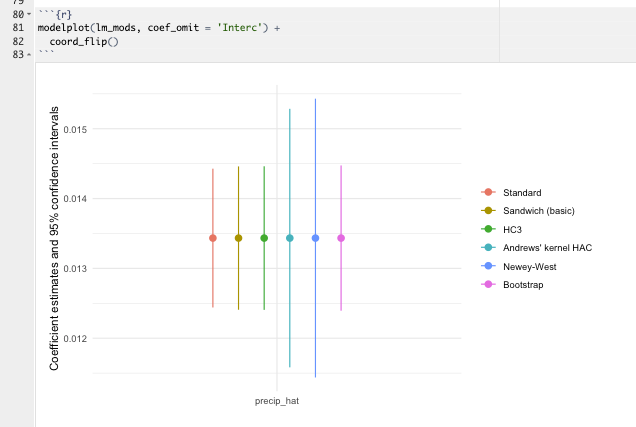

The 95% CI of the Newey-West estimator has the widest range, which makes sense because it accounts for the serially correlated data we are dealing with. When it estimates the confidence interval for the estimate of $\beta$, it widens it to account for the fact that there is heteroskedasticity and autocorrelation present in the data. We can't be as confident in the predictions as we could if we were dealing with homoskedacity and a lack of correlation in the residuals.

The Newey-West estimator is particularly appropriate when dealing with time series data like I am using in this project, so I'm going to use it to handle the standard error here. My bandwidth is going to be 13 (weeks) to account for the seasonality I saw.  

In [26]:
#getting rid of missing values
iv_df = df[
    ["lake_level_change", "precip_3mo", "season"]
].dropna().copy()

# Create season dummy variables
season_dummies = pd.get_dummies(
    iv_df["season"],
    prefix="season",
    drop_first=True,
    dtype=int
)

# Add them to iv_df
iv_df = pd.concat(
    [iv_df, season_dummies],
    axis=1
)

iv_df.head()

,lake_level_change,precip_3mo,season,season_spring,season_summer,season_winter
1,-0.014286,3.3,winter,0,0,1
2,0.014286,5.0,winter,0,0,1
3,0.100000,6.9,winter,0,0,1
4,0.142857,7.4,winter,0,0,1
5,0.057143,7.9,winter,0,0,1


In [28]:
# specifying variables as instruments
iv_model = IV2SLS.from_formula(
    "lake_level_change ~ 1 + "
    "[precip_3mo ~ season_spring + season_summer + season_winter]",
    data=iv_df
)

In [30]:
#unadjusted IV-2SLS summary
iv_standard = iv_model.fit(
    cov_type="unadjusted"
)

print(iv_standard.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:      lake_level_change   R-squared:                      0.4861
Estimator:                    IV-2SLS   Adj. R-squared:                 0.4858
No. Observations:                1396   F-statistic:                    912.20
Date:                Sun, Oct 04 2026   P-value (F-stat)                0.0000
Time:                        22:53:20   Distribution:                  chi2(1)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -0.1873     0.0062    -29.994     0.0000     -0.1995     -0.1750
precip_3mo     0.0134     0.0004     30.203     0.00

In [33]:
# using Newey-West estimator
iv_newey_west = iv_model.fit(
    cov_type="kernel",
    kernel="bartlett",
    bandwidth=13
)

print(iv_newey_west.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:      lake_level_change   R-squared:                      0.4861
Estimator:                    IV-2SLS   Adj. R-squared:                 0.4858
No. Observations:                1396   F-statistic:                    295.04
Date:                Sun, Oct 04 2026   P-value (F-stat)                0.0000
Time:                        22:57:47   Distribution:                  chi2(1)
Cov. Estimator:                kernel                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -0.1873     0.0107    -17.439     0.0000     -0.2083     -0.1662
precip_3mo     0.0134     0.0008     17.177     0.00

We can see a significant difference in the SE and in the CI. The second stage OLS from above gave 0.001 as the standard error, but the Newey-West estimator gives 0.0008 and a 95% confidence interval between 0.0119 and 0.0149. That's a broader range that better acounts for what's happening with the residuals than the standard way of handling the SE.